# **Prerequisite Operations**

In [12]:
#@title Installing Dependencies

%pip install tqdm torchvision tensorboard scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [13]:
#@title Requirements

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.notebook import tqdm
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score, recall_score, 
    accuracy_score, f1_score, roc_curve, auc, ConfusionMatrixDisplay, balanced_accuracy_score
)
import matplotlib.pyplot as plt

DATA_DIR = "aggregated"
LOG_DIR = "logs"
MODEL_SAVE_PATH = "best_model_efficientnetv2.pth"
BATCH_SIZE = 8
EPOCHS = 30
LR = 5e-4
IMAGE_SIZE = 224
SEED = 42
PATIENCE = 5

CLASS_NAMES = ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']
n_classes = len(CLASS_NAMES)


In [14]:
#@title Choosing Resources & Determinism

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


# **Data Processing**

In [15]:
#@title Custom Multi-Label Dataset

class TransformSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        original_dataset = self.subset.dataset
        idx = self.subset.indices[index]
        img_path, label = original_dataset.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label
    def __len__(self):
        return len(self.subset)

class MultiLabelImageFolder(Dataset):
    VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    def __init__(self, root, class_names, transform=None):
        self.root = root
        self.class_names = class_names
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples = self._load_samples()
    def _folder_to_multihot(self, folder_name):
        vec = torch.zeros(len(self.class_names), dtype=torch.float32)
        for token in folder_name.split('_'):
            if token in self.class_to_idx:
                vec[self.class_to_idx[token]] = 1.0
        return vec
    def _load_samples(self):
        samples = []
        for folder in sorted(os.listdir(self.root)):
            folder_path = os.path.join(self.root, folder)
            if not os.path.isdir(folder_path): continue
            label = self._folder_to_multihot(folder)
            if label.sum() == 0: continue
            for fname in os.listdir(folder_path):
                if os.path.splitext(fname)[1].lower() in self.VALID_EXTENSIONS:
                    samples.append((os.path.join(folder_path, fname), label))
        print(f'Loaded {len(samples)} images total.')
        return samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, label


In [16]:
#@title Preprocessing Data

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = MultiLabelImageFolder(root=DATA_DIR, class_names=CLASS_NAMES, transform=None)
total = len(full_dataset)
train_size = int(total * 0.70)
val_size = int(total * 0.15)
test_size = total - train_size - val_size

train_subset, val_subset, test_subset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(SEED)
)

train_dataset = TransformSubset(train_subset, transform=train_transform)
val_dataset = TransformSubset(val_subset, transform=val_test_transform)
test_dataset = TransformSubset(test_subset, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Loaded 4543 images total.


In [17]:
#@title Assigning weights to classes

label_counts = torch.zeros(n_classes)
total_train  = 0
print("Calculating class distribution weights...")
for _, y in tqdm(train_loader):
    label_counts += y.sum(dim=0)
    total_train  += y.size(0)

neg_counts = total_train - label_counts
class_weights_tensor = torch.sqrt(neg_counts / label_counts.clamp(min=1)).to(device)
print(f'Softened Positive class weights: {class_weights_tensor.cpu().numpy()}')


Calculating class distribution weights...


  0%|          | 0/398 [00:00<?, ?it/s]

Softened Positive class weights: [2.2335398 2.320677  2.2669353 2.812039  2.3179183 2.2827477 2.4856246
 2.5221243 2.2880766 2.4921646 2.5460465 2.4987469]


# **Deep Learning Models Creation, Training, Evaluating**

In [18]:
#@title Deep Models EfficientNetV2

def create_model(num_labels):
    model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-3:].parameters():
        param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_labels)
    )
    return model

model = create_model(n_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor)


In [19]:
#@title Training the Models

best_val_loss = float('inf')
patience_counter = 0
best_thresholds = np.full(n_classes, 0.5)

hist = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(EPOCHS):
    model.train()
    running_loss, train_correct = 0.0, 0.0
    for X, y in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]'):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        train_correct += ((torch.sigmoid(outputs) > 0.5) == y).float().sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc = train_correct / (len(train_dataset) * n_classes)

    model.eval()
    val_loss_sum, val_correct = 0.0, 0.0
    val_probs, val_labels = [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            val_loss_sum += loss.item() * X.size(0)
            val_correct += ((torch.sigmoid(outputs) > 0.5) == y).float().sum().item()
            val_probs.append(torch.sigmoid(outputs).cpu().numpy())
            val_labels.append(y.cpu().numpy())

    val_loss = val_loss_sum / len(val_dataset)
    val_acc = val_correct / (len(val_dataset) * n_classes)

    hist['loss'].append(train_loss)
    hist['val_loss'].append(val_loss)
    hist['accuracy'].append(train_acc)
    hist['val_accuracy'].append(val_acc)

    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    if val_loss < best_val_loss - 0.001:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        v_labels = np.vstack(val_labels)
        v_probs = np.vstack(val_probs)
        for i in range(n_classes):
            if np.sum(v_labels[:, i]) == 0: continue
            precisions, recalls, thresholds = roc_curve(v_labels[:, i], v_probs[:, i])
            with np.errstate(divide='ignore', invalid='ignore'):
                f1_scores = np.nan_to_num((2 * precisions * recalls) / (precisions + recalls))
            valid_indices = np.where((thresholds >= 0.1) & (thresholds <= 0.9))[0]
            if len(valid_indices) > 0:
                best_thresholds[i] = thresholds[valid_indices[np.argmax(f1_scores[valid_indices])]]
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping triggered! No improvement for {PATIENCE} epochs.')
            break


Epoch 1/30 [Train]:   0%|          | 0/398 [00:00<?, ?it/s]

Epoch 1: train_loss=0.5365, val_loss=0.3248


Epoch 2/30 [Train]:   0%|          | 0/398 [00:00<?, ?it/s]

Epoch 2: train_loss=0.3422, val_loss=0.2638


Epoch 3/30 [Train]:   0%|          | 0/398 [00:00<?, ?it/s]

...

Epoch 13: train_loss=0.1734, val_loss=0.2704


Epoch 14/30 [Train]:   0%|          | 0/398 [00:00<?, ?it/s]

Epoch 14: train_loss=0.1570, val_loss=0.2807


Epoch 15/30 [Train]:   0%|          | 0/398 [00:00<?, ?it/s]

Epoch 15: train_loss=0.1489, val_loss=0.2336
Early stopping triggered! No improvement for 5 epochs.


In [20]:
#@title Generating Testing Set Predictions

print("\n--- Running Predictions on Independent Test Set ---")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()
all_labels, all_probs = [], []

with torch.no_grad():
    for X, y in test_loader:
        all_probs.append(torch.sigmoid(model(X.to(device))).cpu().numpy())
        all_labels.append(y.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)
all_predicts = (all_probs > best_thresholds).astype(float)



--- Running Predictions on Independent Test Set ---


/scratch/local/30891976/ipykernel_3094478/1898944464.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_PATH))


Classification Report (multi-label, per class):
              precision    recall  f1-score   support

         pen     0.6536    0.8772    0.7491       114
       paper     0.6471    0.9083    0.7557       109
        book     0.5389    0.9474    0.6870        95
       clock     0.5868    0.8875    0.7065        80
       phone     0.6883    0.9138    0.7852       116
      laptop     0.5879    0.9238    0.7185       105
       chair     0.7692    0.9412    0.8466        85
        desk     0.5259    0.8659    0.6544        82
      bottle     0.6337    0.9316    0.7543       117
    keychain     0.4785    0.9286    0.6316        84
    backpack     0.8558    0.9780    0.9128        91
  calculator     0.5934    1.0000    0.7448       108

   micro avg     0.6193    0.9258    0.7421      1186
   macro avg     0.6299    0.9253    0.7455      1186
weighted avg     0.6320    0.9258    0.7475      1186
 samples avg     0.7015    0.9407    0.7725      1186



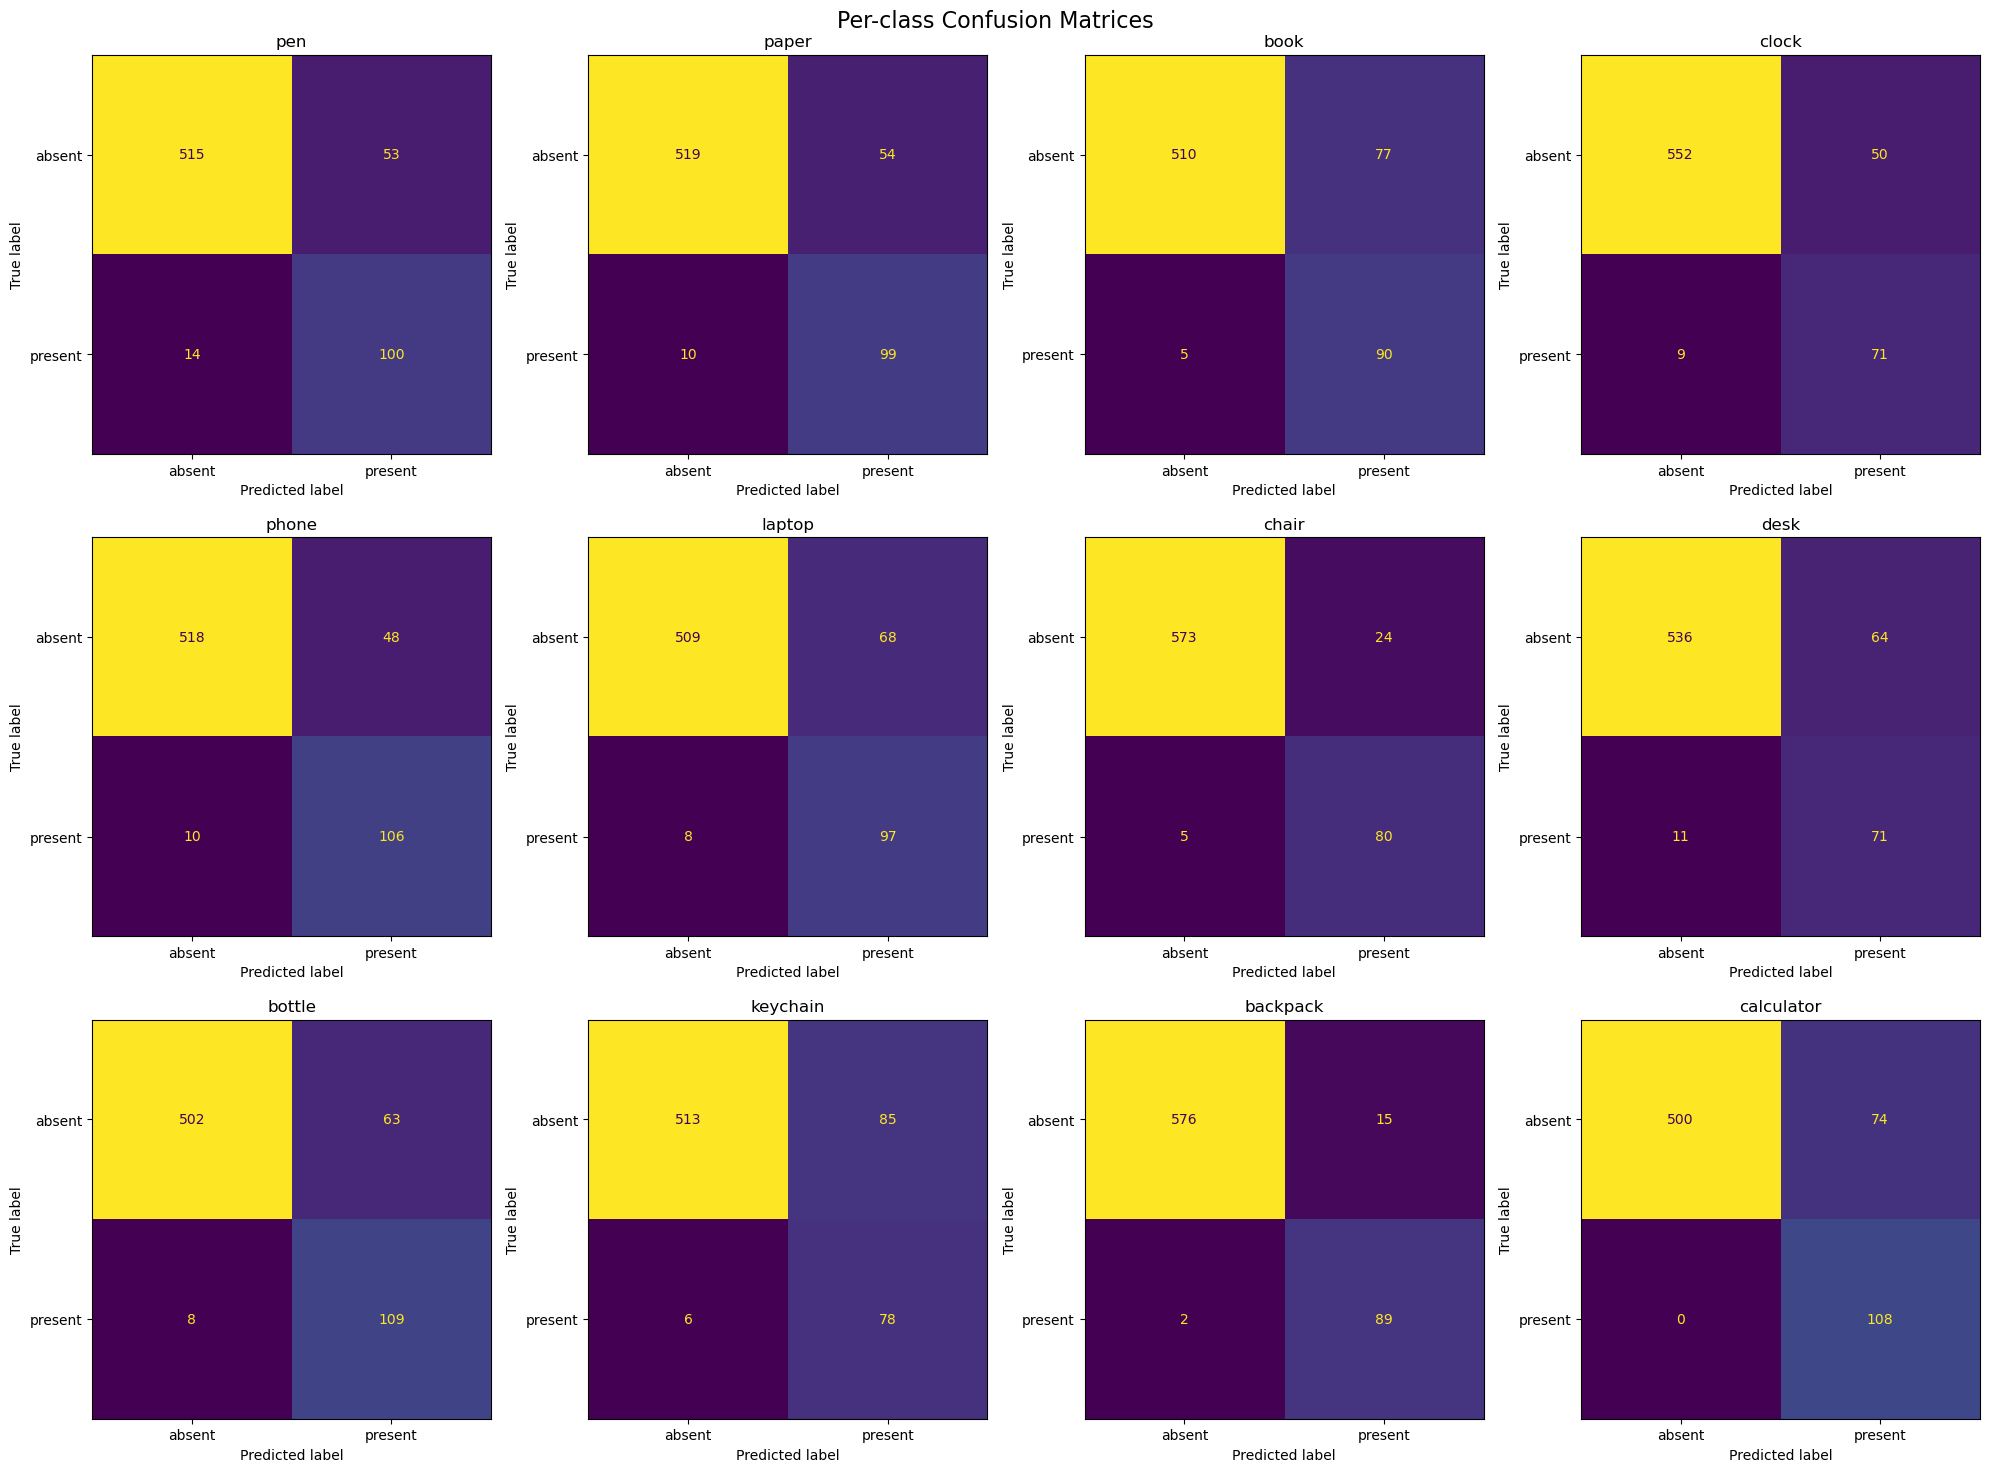


Classwise Balanced Accuracy: ['0.8919', '0.9070', '0.9081', '0.9022', '0.9145', '0.9030', '0.9505', '0.8796', '0.9101', '0.8932', '0.9763', '0.9355']
Mean Balanced Accuracy: 0.9143



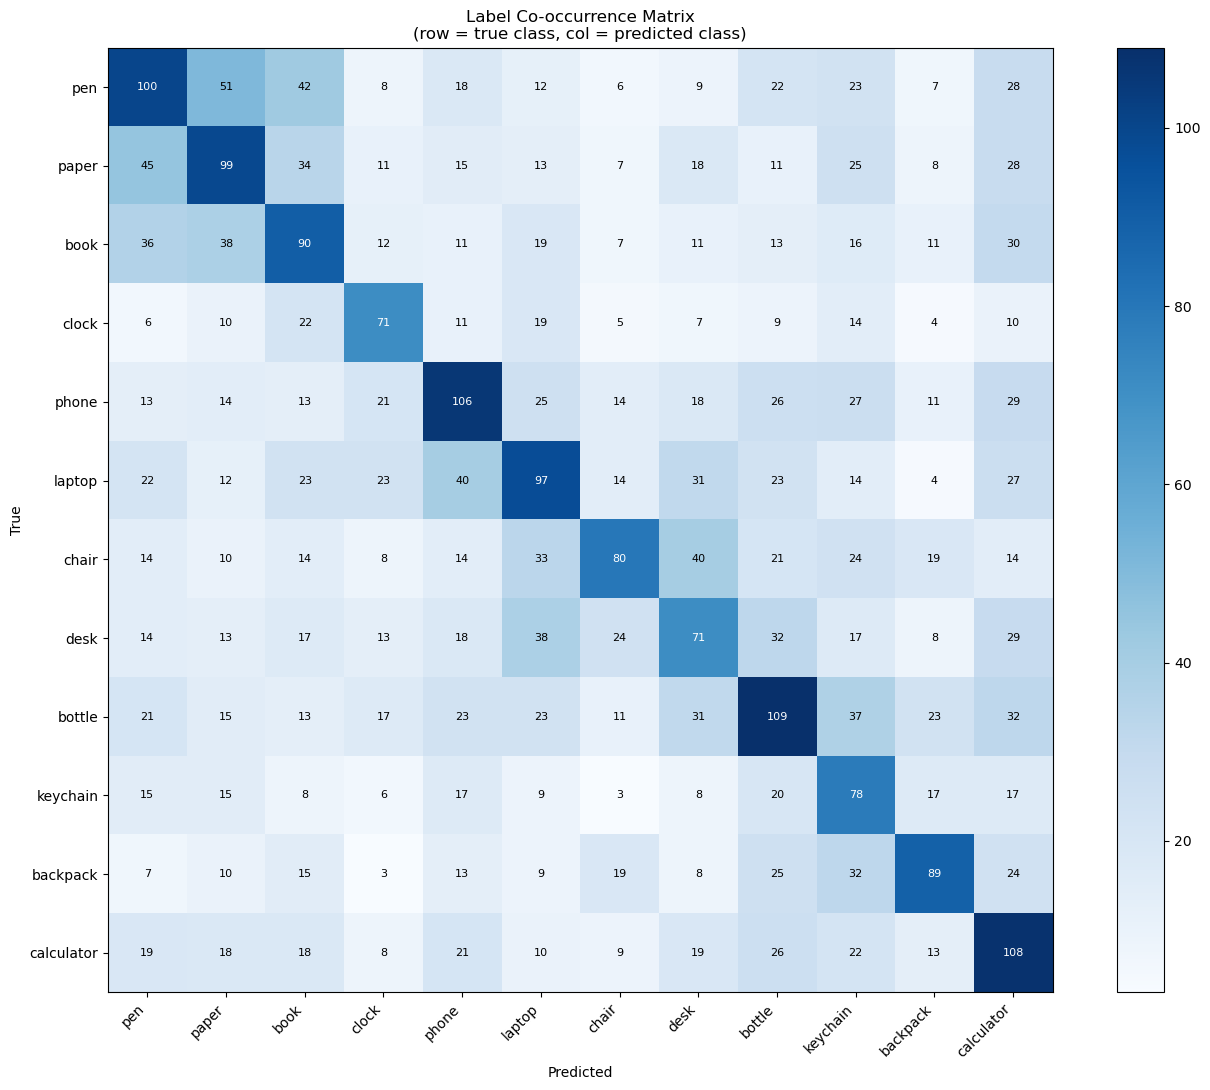

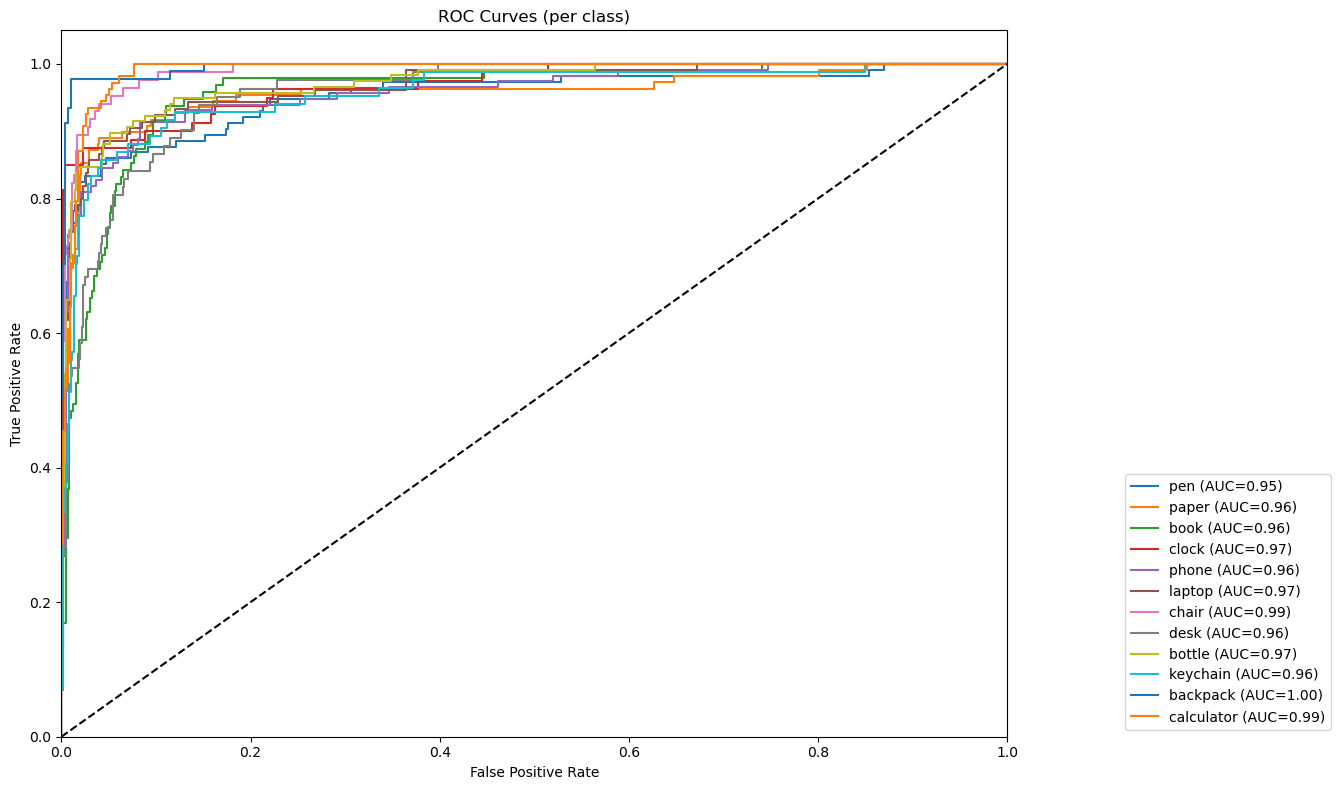

In [21]:
#@title Evaluation Metrics & Deep Diagram Grids

def plot_roc_multilabel(labels, probs, class_names, caption='ROC Curves (per class)'):
    plt.figure(figsize=(14, 8))
    for i, cls in enumerate(class_names):
        if labels[:, i].sum() == 0: continue
        fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(caption)
    plt.legend(loc='lower right', bbox_to_anchor=(1.35, 0.0))
    plt.tight_layout()
    plt.show()

def metrics(labels, predictions, class_names):
    print('Classification Report (multi-label, per class):')
    print(classification_report(labels, predictions, target_names=class_names, digits=4, zero_division=0))
    
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    classwise_bal_acc = []
    for i, cls in enumerate(class_names):
        cm = confusion_matrix(labels[:, i], predictions[:, i])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['absent', 'present'])
        disp.plot(ax=axes[i], colorbar=False)
        axes[i].set_title(cls)
        axes[i].tick_params(axis='x', rotation=0)
        if labels[:, i].sum() > 0:
            classwise_bal_acc.append(balanced_accuracy_score(labels[:, i], predictions[:, i]))
    plt.suptitle('Per-class Confusion Matrices', fontsize=16)
    plt.tight_layout()
    plt.show()

    print('\nClasswise Balanced Accuracy:', [f'{v:.4f}' for v in classwise_bal_acc])
    print('Mean Balanced Accuracy:', f'{np.mean(classwise_bal_acc):.4f}\n')

    cooccurrence = np.zeros((len(class_names), len(class_names)))
    for true_row, pred_row in zip(labels, predictions):
        true_indices = np.where(true_row == 1)[0]
        pred_indices = np.where(pred_row == 1)[0]
        for i in true_indices:
            for j in pred_indices:
                cooccurrence[i, j] += 1
    fig, ax = plt.subplots(figsize=(14, 11))
    im = ax.imshow(cooccurrence, cmap='Blues')
    ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Label Co-occurrence Matrix\n(row = true class, col = predicted class)')
    plt.colorbar(im, ax=ax)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            color = 'white' if cooccurrence[i, j] > cooccurrence.max() * 0.6 else 'black'
            ax.text(j, i, int(cooccurrence[i, j]), ha='center', va='center', fontsize=8, color=color)
    plt.tight_layout()
    plt.show()

metrics(all_labels, all_predicts, CLASS_NAMES)
plot_roc_multilabel(all_labels, all_probs, CLASS_NAMES)


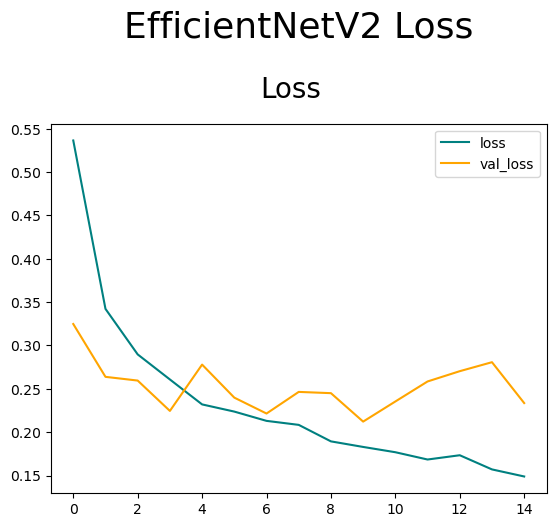

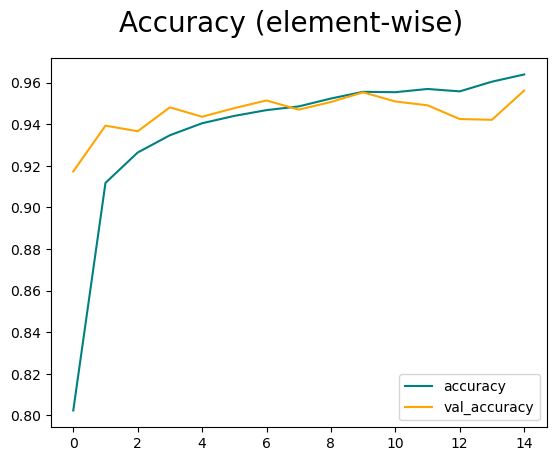

In [22]:
#@title Performance Graphs

fig = plt.figure()
plt.title('EfficientNetV2 Loss\n\n', loc='center', fontsize=26)
plt.plot(hist['loss'],     color='teal',   label='loss')
plt.plot(hist['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper right')
plt.show()

fig = plt.figure()
plt.plot(hist['accuracy'],     color='teal',   label='accuracy')
plt.plot(hist['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy (element-wise)', fontsize=20)
plt.legend(loc='lower right')
plt.show()
